In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

from sklearn.metrics import roc_auc_score

In [59]:
df = pd.read_csv('../data/course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [60]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [61]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']

numerical = [c for c in df.columns if c not in categorical + ['converted']]

In [62]:
def prepare_data(df, categorical, numerical, target='converted'):
    df = df.copy()

    # Report missing values in the features
    missing = df[categorical + numerical].isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print('No missing values in features.')
    else:
        print('Missing values found:')
        print(missing)

    # Fill missing values
    df[categorical] = df[categorical].fillna('NA')
    df[numerical] = df[numerical].fillna(0.0)

    # The target should not be filled, only reported
    if target in df.columns and df[target].isnull().any():
        n = df[target].isnull().sum()
        print(f'Warning: {n} rows have a missing {target}. Consider dropping them.')

    return df

In [63]:
df = prepare_data(df, categorical, numerical)

df.isnull().sum()   # confirm everything is filled

Missing values found:
lead_source          148
industry             240
employment_status    194
location             208
annual_income        369
lead_score            35
dtype: int64


lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [64]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [65]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values
del df_train['converted']
del df_val['converted']
del df_test['converted']
df_full_train = df_full_train.reset_index(drop=True)

In [66]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']

numerical = [c for c in df.columns if c not in categorical + ['converted']]

In [67]:
def numerical_auc(df_train, y_train, numerical):
    results = []
    for c in numerical:
        auc = roc_auc_score(y_train, df_train[c])
        inverted = False
        if auc < 0.5:
            auc = roc_auc_score(y_train, -df_train[c])
            inverted = True
        results.append({'feature': c, 'auc': auc, 'inverted': inverted})

    return pd.DataFrame(results).sort_values('auc', ascending=False)

In [68]:
df_auc = numerical_auc(df_train, y_train, numerical)
df_auc

,feature,auc,inverted
3,lead_score,0.788225,False
2,interaction_count,0.764920,False
1,number_of_courses_viewed,0.722989,False
0,annual_income,0.608198,False


In [69]:
features = categorical + numerical

dv = DictVectorizer(sparse=False)

train_dicts = df_train[features].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[features].to_dict(orient='records')
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_pred)
round(auc, 3)

0.732

In [70]:
def precision_recall_by_threshold(y_true, y_pred, thresholds):
    y_true = np.asarray(y_true)
    results = []

    for t in thresholds:
        predict_positive = y_pred >= t
        actual_positive = y_true == 1

        tp = (predict_positive & actual_positive).sum()
        fp = (predict_positive & ~actual_positive).sum()
        fn = (~predict_positive & actual_positive).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        results.append({'threshold': t, 'precision': precision, 'recall': recall})

    return pd.DataFrame(results)


thresholds = np.linspace(0, 1, 101)
df_scores = precision_recall_by_threshold(y_val, y_pred, thresholds)

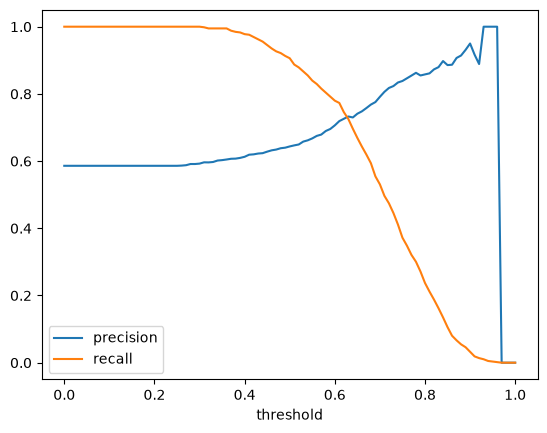

In [71]:
plt.plot(df_scores.threshold, df_scores.precision, label='precision')
plt.plot(df_scores.threshold, df_scores.recall, label='recall')
plt.xlabel('threshold')
plt.legend()
plt.show()

In [72]:
valid = df_scores[(df_scores.precision > 0) | (df_scores.recall > 0)].copy()
valid['diff'] = (valid.precision - valid.recall).abs()

valid.sort_values('diff').head()

,threshold,precision,recall,diff
63,0.63,0.732759,0.725256,0.007503
62,0.62,0.725914,0.745734,0.019820
64,0.64,0.729875,0.696246,0.033629
61,0.61,0.719048,0.773038,0.053990
65,0.65,0.741021,0.668942,0.072079


In [73]:
p = df_scores.precision
r = df_scores.recall

df_scores['f1'] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
df_scores.sort_values('f1', ascending=False).head()

,threshold,precision,recall,f1
41,0.41,0.619048,0.976109,0.757616
42,0.42,0.620087,0.969283,0.756325
43,0.43,0.622517,0.962457,0.756032
45,0.45,0.628118,0.945392,0.754768
44,0.44,0.623608,0.955631,0.754717


In [74]:
def train(df, y, features, C=1.0):
    dicts = df[features].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X, y)

    return dv, model


def predict(df, dv, model, features):
    dicts = df[features].to_dict(orient='records')
    X = dv.transform(dicts)
    return model.predict_proba(X)[:, 1]


def cross_validate(df_full_train, features, target='converted', C=1.0, n_splits=5):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_tr = df_full_train.iloc[train_idx]
        df_va = df_full_train.iloc[val_idx]

        y_tr = df_tr[target].values
        y_va = df_va[target].values

        dv, model = train(df_tr, y_tr, features, C=C)
        y_pred = predict(df_va, dv, model, features)

        scores.append(roc_auc_score(y_va, y_pred))

    return scores

In [75]:
features = categorical + numerical

scores = cross_validate(df_full_train, features)

print(np.round(scores, 3))
print(f'mean={np.mean(scores):.3f} std={np.std(scores):.3f}')

[0.731 0.73  0.736 0.741 0.721]
mean=0.732 std=0.007


In [76]:
def tune_c_cv(df_full_train, features, C_values, target='converted'):
    results = []
    for C in C_values:
        scores = cross_validate(df_full_train, features, target=target, C=C)
        mean, std = round(np.mean(scores), 3), round(np.std(scores), 3)
        results.append({'C': C, 'mean': mean, 'std': std})
        print(f'C={C}: mean={mean} std={std}')

    return pd.DataFrame(results)

In [77]:
C_values = [0.000001, 0.001, 1]

df_cv = tune_c_cv(df_full_train, features, C_values)
df_cv

C=1e-06: mean=0.617 std=0.019
C=0.001: mean=0.749 std=0.01
C=1: mean=0.732 std=0.007


,C,mean,std
0,0.000001,0.617,0.019
1,0.001000,0.749,0.010
2,1.000000,0.732,0.007


In [78]:
df_cv.sort_values(['mean', 'std', 'C'], ascending=[False, True, True]).iloc[0]

C       0.001
mean    0.749
std     0.010
Name: 1, dtype: float64

In [79]:
15/60

0.25